# Gold Price Prediction — Standardized ML Pipeline

Predict the gold ETF price **GLD** (regression) from other daily market indicators, using a clean, leakage-free pipeline.

**Pipeline order:** Basic Analysis -> Train/Test Split -> EDA -> Feature Engineering -> Encoding -> Outlier Handling -> Scaling -> Models.

> All features here are numeric market indicators, so the encoding step has nothing to convert. Every data-driven step is still fit on the **training set only**.
> For a forecasting-correct (chronological) version, see the separate time-series notebook.

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy import stats
from scipy.stats.mstats import winsorize

sns.set()

## 1. Basic Analysis

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Gold Price Prediction/gold_price_data.csv')
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
print('Shape:', df.shape)
df.info()

Shape: (2290, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [5]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [6]:
df.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


## 2. Train-Test Split (done early to prevent data leakage)

In [7]:
X = df.drop(columns='GLD')
y = df['GLD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1832, 5) | Test: (458, 5)


## 3. EDA (training data only)

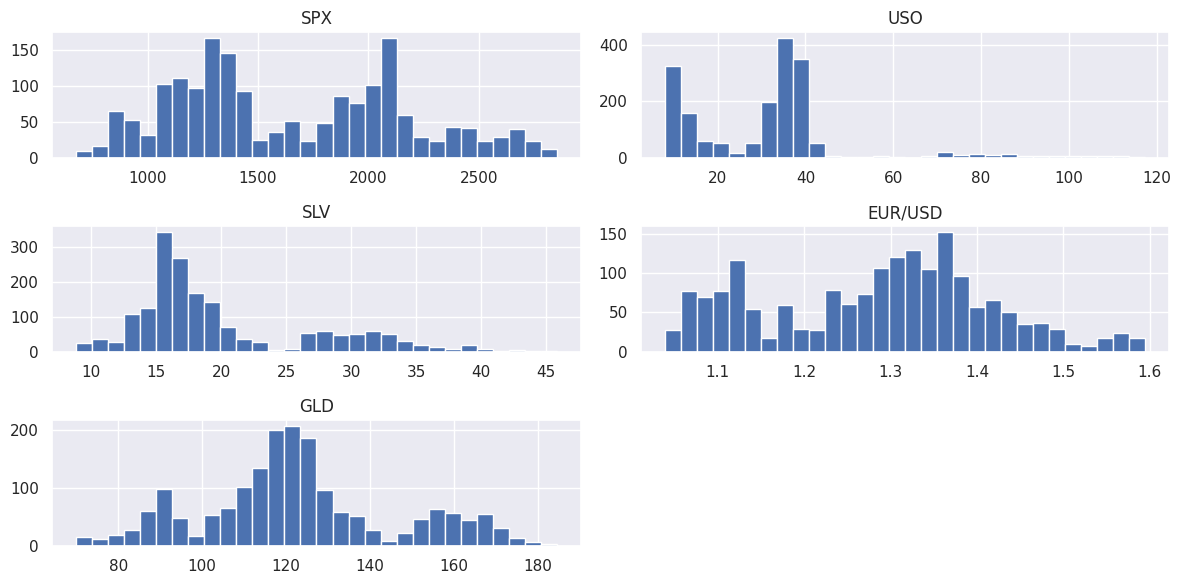

In [8]:
train_df = X_train.copy()
train_df['GLD'] = y_train

train_df[['SPX', 'USO', 'SLV', 'EUR/USD', 'GLD']].hist(figsize=(12, 6), bins=30)
plt.tight_layout()
plt.show()

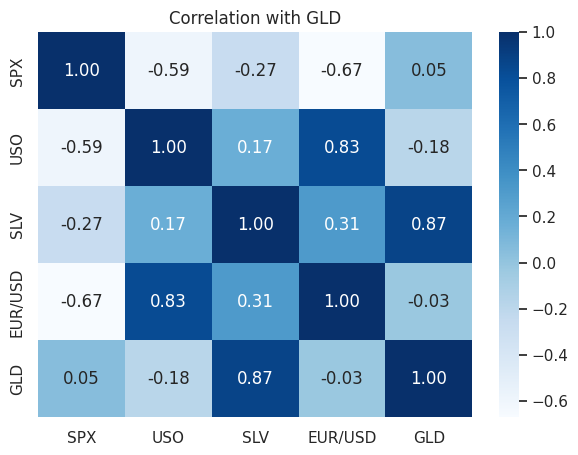

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation with GLD')
plt.show()

## 4. Feature Engineering

The only non-numeric column is `Date`, which we drop (this notebook treats the data as plain regression, not a time series). No other engineered features are needed since the inputs are already clean numeric indicators.

In [10]:
def add_features(data):
    data = data.copy()
    if 'Date' in data.columns:
        data = data.drop(columns=['Date'])
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
X_train.head()

,SPX,USO,SLV,EUR/USD
476,1138.500000,39.790001,16.889999,1.361693
1958,2202.939941,10.630000,15.800000,1.063886
248,700.820007,24.480000,12.770000,1.256408
2231,2656.000000,11.890000,15.570000,1.225280
1325,1838.880005,33.040001,19.420000,1.366998


## 5. Encoding (One-Hot for nominal categoricals)

There are no categorical columns left to encode, so this step is a safe no-op (kept for a consistent pipeline). We still cast to float for the scaler.

In [11]:
cat_cols = []  # no categorical features in this dataset

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
X_train.head()

,SPX,USO,SLV,EUR/USD
476,1138.500000,39.790001,16.889999,1.361693
1958,2202.939941,10.630000,15.800000,1.063886
248,700.820007,24.480000,12.770000,1.256408
2231,2656.000000,11.890000,15.570000,1.225280
1325,1838.880005,33.040001,19.420000,1.366998


## 6. Outlier Handling — IQR vs Z-score vs Winsorization (auto-select best)

Applied to the **training set only**, on the numeric predictor columns.

In [12]:
outlier_cols = ['SPX', 'USO', 'SLV', 'EUR/USD']

def cv_score(Xc, yc):
    model = RandomForestRegressor(n_estimators=100, random_state=2)
    return cross_val_score(model, Xc, yc, cv=5, scoring='r2').mean()

def iqr_clean(X, y, cols):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        iqr = q3 - q1
        mask &= X[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return X[mask], y[mask]

def zscore_clean(X, y, cols):
    z = np.abs(stats.zscore(X[cols]))
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]

def winsor_clean(X, y, cols, limit=0.05):
    Xw = X.copy()
    for c in cols:
        Xw[c] = np.asarray(winsorize(Xw[c], limits=[limit, limit]))
    return Xw, y

scores = {}
scores['none'] = cv_score(X_train, y_train)
scores['iqr'] = cv_score(*iqr_clean(X_train, y_train, outlier_cols))
scores['zscore'] = cv_score(*zscore_clean(X_train, y_train, outlier_cols))
scores['winsorize'] = cv_score(*winsor_clean(X_train, y_train, outlier_cols))

for k, v in scores.items():
    print(f'{k:10s} CV R2: {v:.4f}')

best_outlier = max(scores, key=scores.get)
print('\nBest outlier method:', best_outlier)

none       CV R2: 0.9884
iqr        CV R2: 0.9854
zscore     CV R2: 0.9869
winsorize  CV R2: 0.9869

Best outlier method: none


In [13]:
if best_outlier == 'iqr':
    X_train, y_train = iqr_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'zscore':
    X_train, y_train = zscore_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'winsorize':
    X_train, y_train = winsor_clean(X_train, y_train, outlier_cols)

print('Training rows after outlier handling:', X_train.shape[0])

Training rows after outlier handling: 1832


## 7. Feature Scaling — Standard vs MinMax vs Robust (auto-select best)

In [14]:
scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(), 'robust': RobustScaler()}

scaler_scores = {}
for name, sc in scalers.items():
    X_scaled = sc.fit_transform(X_train)
    scaler_scores[name] = cross_val_score(KNeighborsRegressor(), X_scaled, y_train, cv=5, scoring='r2').mean()
    print(f'{name:10s} CV R2 (KNN): {scaler_scores[name]:.4f}')

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print('\nBest scaler:', best_scaler_name)

scaler = scalers[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard   CV R2 (KNN): 0.9905
minmax     CV R2 (KNN): 0.9904
robust     CV R2 (KNN): 0.9897

Best scaler: standard


## 8. Model Training & Comparison

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=2),
    'KNN': KNeighborsRegressor(),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,KNN,0.989093,1.394433,2.398534
1,Random Forest,0.988723,1.343390,2.438893
2,Gradient Boosting,0.976418,2.292221,3.526787
3,Linear Regression,0.865789,5.911487,8.413614


In [16]:
best_row = results_df.iloc[0]
print('Best model :', best_row['Model'])
print('Test R2    :', round(best_row['R2'], 4))
print('Test MAE   :', round(best_row['MAE'], 4))
print('Test RMSE  :', round(best_row['RMSE'], 4))

Best model : KNN
Test R2    : 0.9891
Test MAE   : 1.3944
Test RMSE  : 2.3985
